# Video Idea Leads

This notebook finds YouTube video idea leads: videos that performed abnormally well relative to the creator's weight class, not merely videos from already-huge channels. The core heuristic is to look for small or mid-sized channels punching above their subscriber and maturity class (for example, a 10k-subscriber channel getting 1M views), using subscribers, video count, per-video views, and comments as triangulation metrics.

Shorts defense has two layers. First, this notebook excludes videos of 60 seconds or less by default. The product concern is that a Short reaching 1M views is a weaker video-idea signal than a long-form video reaching 1M views, because Shorts often accumulate views through a low-intent feed mechanic rather than deliberate audience demand. The exclusion runs inside `load_analysis_frame` before enrichment, so channel-relative baselines and weight-class norms are computed from long-form videos only; matching snapshots are filtered to the surviving video set too.

Second, the final composite shortlist can run a Shorts verification probe. Duration alone is insufficient because YouTube raised the Shorts limit to 3 minutes in Oct 2024, so Shorts in the 61-180s band can slip past a 60-second cutoff. The probe sends `HEAD https://www.youtube.com/shorts/<video_id>` only for over-fetched top candidates: HTTP 200 confirms a Short, while a redirect means the video is not a Short. Confirmed Shorts are dropped before the final top-N truncation; network errors or timeouts are fail-open (`undetermined`) and are kept deliberately so a transient probe failure cannot silently remove a real lead.

The two slow steps (loading/enriching the joined frame and running the six scoring algorithms) are checkpointed to Parquet under `data/cache/leads/`, so a kernel restart reloads results instead of recomputing them for several minutes. Entries are keyed by the database contents (row counts and max ids of the tables the analysis reads), by the analysis parameters, and by a hash of the `scripts/RecomendationAnalysis` sources; ingesting new rows, tuning a parameter, or editing an algorithm therefore produces a fresh entry rather than a stale hit. Content keying is used instead of file mtime because collectors write to `skimmer.db` continuously, so an mtime key would miss on nearly every run; set `CACHE_DB_FINGERPRINT = 'path'` to pin the cache to whatever was computed last regardless of new ingests. Set `USE_CACHE = False` to bypass the cache entirely or `REFRESH_CACHE = True` to recompute and overwrite. Cache read/write failures are non-fatal and fall back to recomputation.

- Default DB path: `data/skimmer.db`
- Override with env var: `SKIMMER_DB_PATH`
- Outputs a composite lead table plus a CSV export in `data/output/`

Algorithm columns:

- `breakout_outliers`: small-channel videos with extreme views-per-subscriber.
- `weight_class_performance`: top percentile videos within subscriber and video-count peer groups.
- `channel_relative`: videos far above their own channel's typical view baseline.
- `velocity`: videos with unusually strong publish velocity or recent re-acceleration.
- `engagement`: videos with unusually high comment/like resonance for their class.
- `topics`: recurring title themes among already-identified outlier leads.

## 1. Setup

In [1]:
import copy
import html
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'scripts' / 'RecomendationAnalysis').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError('Could not locate the skimmer repository root from the current directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.RecomendationAnalysis import checkpoint, data_access, leads as ra_leads, metrics
from scripts.RecomendationAnalysis.algorithms import topics

DEFAULT_DB_PATH = Path('data/skimmer.db')
_env_db_path = os.environ.get('SKIMMER_DB_PATH')
DB_PATH = Path(_env_db_path).expanduser() if _env_db_path else REPO_ROOT / DEFAULT_DB_PATH
if not DB_PATH.is_absolute():
    DB_PATH = REPO_ROOT / DB_PATH
DB_PATH = data_access.resolve_db_path(DB_PATH)

print(f'Using database: {DB_PATH.resolve()}')

Using database: /home/orangepi/code_projects/skimmer/data/skimmer.db


## 2. Parameters

Edit this single cell to tune the notebook. All downstream cells read from these values.

In [2]:
# PARAMETERS
TOP_N = 100
EXCLUDE_SHORTS = True  # Exclude videos at or below the Shorts duration cutoff from all downstream analysis.
SHORTS_MAX_DURATION_SECONDS = 60  # Duration cutoff for the bulk Shorts filter before enrichment/baselines.
DROP_UNKNOWN_DURATION = False  # Keep videos with missing duration instead of treating them as Shorts.

# Network note: Shorts verification is the only notebook behavior that makes network requests.
# Set VERIFY_SHORTS = False to make the notebook fully offline.
VERIFY_SHORTS = True  # Probe the final over-fetched shortlist via YouTube Shorts URLs.
VERIFY_SHORTS_MAX_WORKERS = 8  # Concurrent HEAD requests for the final-shortlist probe.
VERIFY_SHORTS_TIMEOUT = 8.0  # Per-request timeout in seconds; timeouts are kept fail-open.
VERIFY_SHORTS_OVER_FETCH = 2.0  # Probe TOP_N * this many candidates before dropping confirmed Shorts.
VERIFY_SHORTS_CACHE = None  # None uses data/output/shorts_probe_cache.json for cheap re-runs.

# Checkpoint cache: the slow load/enrich and algorithm-scoring steps are persisted as Parquet
# so a kernel restart reloads them instead of recomputing for several minutes.
USE_CACHE = True  # False bypasses the cache entirely (no reads, no writes).
REFRESH_CACHE = False  # True recomputes the slow steps and overwrites the cached entries.
CACHE_DIR = None  # None uses data/cache/leads/.
# 'content' keys on row counts of the tables the analysis reads, so unrelated collector writes do not
# invalidate the cache. 'mtime' keys on file size/mtime; 'path' ignores data changes entirely.
CACHE_DB_FINGERPRINT = 'content'

WEIGHTS = copy.deepcopy(ra_leads.DEFAULT_WEIGHTS)

PARAMS = {
    name: copy.deepcopy(getattr(module, 'DEFAULT_PARAMS', {}))
    for name, module in ra_leads.ALGORITHMS.items()
}
# Keep topic extraction on the stdlib path by default; the sklearn path can be memory-heavy on the full corpus.
PARAMS['topics']['use_sklearn'] = False

FILTERS = {
    'max_per_channel': 3,
    # Optional examples:
    # 'max_subscribers': 200_000,
    # 'min_views': 25_000,
    # 'sub_class': ['1k-10k', '10k-50k', '50k-200k'],
}

EXPORT = True
EXPORT_PATH = REPO_ROOT / 'data' / 'output' / f"{datetime.now().strftime('%Y-%m-%d%H%M%S')}.csv"

display(pd.DataFrame({'algorithm': list(WEIGHTS), 'weight': list(WEIGHTS.values())}))
print(f'Shorts filter: exclude_shorts={EXCLUDE_SHORTS}, cutoff_seconds={SHORTS_MAX_DURATION_SECONDS}, drop_unknown_duration={DROP_UNKNOWN_DURATION}')
print(f'Shorts probe: verify_shorts={VERIFY_SHORTS}, max_workers={VERIFY_SHORTS_MAX_WORKERS}, timeout={VERIFY_SHORTS_TIMEOUT}, over_fetch={VERIFY_SHORTS_OVER_FETCH}, cache={VERIFY_SHORTS_CACHE}')
print('Network note: VERIFY_SHORTS controls the only network traffic in this notebook; set VERIFY_SHORTS=False for a fully offline run.')
print(f'Checkpoint cache: use_cache={USE_CACHE}, refresh={REFRESH_CACHE}, db_fingerprint={CACHE_DB_FINGERPRINT}, dir={checkpoint.resolve_cache_dir(CACHE_DIR)}')
print(f'Export path: {EXPORT_PATH}')


,algorithm,weight
0,breakout_outliers,1.35
1,weight_class_performance,1.35
2,channel_relative,1.05
3,velocity,0.85
4,engagement,0.60
5,topics,0.35


Shorts filter: exclude_shorts=True, cutoff_seconds=60, drop_unknown_duration=False
Shorts probe: verify_shorts=True, max_workers=8, timeout=8.0, over_fetch=2.0, cache=None
Network note: VERIFY_SHORTS controls the only network traffic in this notebook; set VERIFY_SHORTS=False for a fully offline run.
Export path: /home/orangepi/code_projects/skimmer/data/output/2026-07-31082319.csv


## 3. Data Load + Corpus Summary

In [3]:
# Slow step: loads and enriches the latest video/channel frame and optional video snapshots once.
# The configured shorts filter is applied inside load_analysis_frame before metrics.enrich,
# so every downstream table and plot reuses this long-form-only analysis frame.
# Both the raw joined frame and the enriched frame are checkpointed to Parquet, so a kernel
# restart reloads them unless the database changed, the parameters changed, or REFRESH_CACHE is set.
FRAME_KWARGS = {
    'with_snapshots': True,
    'exclude_shorts': EXCLUDE_SHORTS,
    'shorts_max_duration_seconds': SHORTS_MAX_DURATION_SECONDS,
    'drop_unknown_duration': DROP_UNKNOWN_DURATION,
}

raw_frames, raw_from_cache = checkpoint.cached_frames(
    checkpoint.make_key('raw_joined', DB_PATH, db_fingerprint_mode=CACHE_DB_FINGERPRINT),
    lambda: {'raw_df': data_access.load_joined(db_path=DB_PATH)},
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
)
raw_df = raw_frames['raw_df']
raw_duration_flags = metrics.add_duration_flags(raw_df, max_duration_seconds=SHORTS_MAX_DURATION_SECONDS)
raw_is_short = raw_duration_flags['is_short']
raw_unknown_duration = pd.to_numeric(raw_df['duration_seconds'], errors='coerce').isna()

full_df, snapshots, frame_from_cache = checkpoint.load_analysis_frame_cached(
    DB_PATH,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
    db_fingerprint_mode=CACHE_DB_FINGERPRINT,
    **FRAME_KWARGS,
)
print(f"Raw joined frame: {'loaded from cache' if raw_from_cache else 'computed'}.")
print(f"Analysis frame: {'loaded from cache' if frame_from_cache else 'computed'}.")

filtered_duration = pd.to_numeric(full_df['duration_seconds'], errors='coerce')
filter_summary = pd.DataFrame(
    [
        {'metric': 'videos_before_shorts_filter', 'value': len(raw_df)},
        {'metric': 'videos_after_shorts_filter', 'value': len(full_df)},
        {'metric': 'shorts_removed', 'value': int(raw_is_short.fillna(False).sum()) if EXCLUDE_SHORTS else 0},
        {'metric': 'unknown_duration_videos_before', 'value': int(raw_unknown_duration.sum())},
        {'metric': 'unknown_duration_videos_retained', 'value': int(filtered_duration.isna().sum())},
        {'metric': 'shorts_cutoff_seconds', 'value': SHORTS_MAX_DURATION_SECONDS},
    ]
)
display(filter_summary)
print('Shorts are excluded from the shared analysis frame used by every downstream section.' if EXCLUDE_SHORTS else 'Shorts exclusion is disabled; downstream sections include all durations.')

known_duration = pd.to_numeric(raw_df['duration_seconds'], errors='coerce').dropna()
duration_summary = pd.DataFrame(
    [
        {'bucket': '<= 60s (shorts)', 'videos': int((known_duration <= SHORTS_MAX_DURATION_SECONDS).sum())},
        {'bucket': '61s-5m', 'videos': int(((known_duration > SHORTS_MAX_DURATION_SECONDS) & (known_duration <= 300)).sum())},
        {'bucket': '5m-20m', 'videos': int(((known_duration > 300) & (known_duration <= 1200)).sum())},
        {'bucket': '> 20m', 'videos': int((known_duration > 1200).sum())},
        {'bucket': 'unknown duration', 'videos': int(raw_unknown_duration.sum())},
    ]
)
display(duration_summary)

summary = pd.DataFrame(
    [
        {'metric': 'videos', 'value': len(full_df)},
        {'metric': 'snapshot_rows', 'value': 0 if snapshots is None else len(snapshots)},
        {
            'metric': 'videos_with_2plus_snapshots',
            'value': 0
            if snapshots is None or snapshots.empty
            else int(snapshots.groupby('video_id', observed=True).size().ge(2).sum()),
        },
        {'metric': 'channels', 'value': full_df['channel_id'].nunique() if 'channel_id' in full_df else np.nan},
    ]
)
display(summary)

published = pd.to_datetime(full_df.get('published_at'), errors='coerce', utc=True)
display(pd.DataFrame({'published_at_min': [published.min()], 'published_at_max': [published.max()]}))

class_crosstab = pd.crosstab(full_df['sub_class'], full_df['video_count_class'], dropna=False)
display(class_crosstab)

key_metrics = [
    'subscribers',
    'video_count',
    'views',
    'comments',
    'views_per_sub',
    'channel_relative_multiple',
    'comment_rate',
    'views_per_day',
    'video_age_days',
]
null_rates = (
    full_df[key_metrics]
    .isna()
    .mean()
    .rename('null_rate')
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'index': 'metric'})
)
display(null_rates)


No usable vidiq channel rows found for 49 missing channels.


No usable vidiq channel rows found for 49 missing channels.


,metric,value
0,videos_before_shorts_filter,258454
1,videos_after_shorts_filter,207768
2,shorts_removed,50686
3,unknown_duration_videos_before,2867
4,unknown_duration_videos_retained,2867
5,shorts_cutoff_seconds,60


Shorts are excluded from the shared analysis frame used by every downstream section.


,bucket,videos
0,<= 60s (shorts),50686
1,61s-5m,52032
2,5m-20m,55238
3,> 20m,97631
4,unknown duration,2867


,metric,value
0,videos,207768
1,snapshot_rows,392178
2,videos_with_2plus_snapshots,90211
3,channels,10666


,published_at_min,published_at_max
0,2026-06-23 03:10:24+00:00,2026-07-30 17:25:21+00:00


video_count_class,<50,50-300,300-1000,1000+,unknown
sub_class,,,,,
<1k,6612,3471,1089,414,0
1k-10k,8325,13329,4690,5148,0
10k-50k,2447,12762,6334,10874,0
50k-200k,997,5645,7949,16667,0
200k-1M,252,3549,8906,32025,0
1M+,69,1159,5524,49216,0
unknown,0,0,0,0,315


,metric,null_rate
0,subscribers,0.15
1,video_count,0.15
2,views,0.00
3,comments,1.78
4,views_per_sub,0.17
5,channel_relative_multiple,3.28
6,comment_rate,2.63
7,views_per_day,0.00
8,video_age_days,0.00


## 4. Shared Display Helpers

In [4]:
def _compact_number(value):
    if pd.isna(value):
        return ''
    try:
        number = float(value)
    except (TypeError, ValueError):
        return value
    absolute = abs(number)
    if absolute >= 1_000_000_000:
        return f'{number / 1_000_000_000:.2f}B'
    if absolute >= 1_000_000:
        return f'{number / 1_000_000:.2f}M'
    if absolute >= 1_000:
        return f'{number / 1_000:.1f}k'
    return f'{number:,.0f}'


def _format_value(value):
    if pd.isna(value):
        return ''
    if isinstance(value, (int, np.integer)):
        return f'{value:,}'
    if isinstance(value, (float, np.floating)):
        if abs(value) >= 1000:
            return _compact_number(value)
        return f'{value:.3f}'.rstrip('0').rstrip('.')
    return str(value)


def _anchor(url, text):
    text = '' if pd.isna(text) else str(text)
    if pd.isna(url) or not str(url).strip():
        return html.escape(text)
    return f'<a href="{html.escape(str(url), quote=True)}" target="_blank">{html.escape(text)}</a>'


def display_link_table(frame, columns, limit=25, link_title=True):
    available = [column for column in columns if column in frame.columns]
    table = frame.head(limit).loc[:, available].copy()
    if link_title and 'title' in table.columns and 'video_url' in frame.columns:
        urls = frame.head(limit)['video_url']
        table['title'] = [_anchor(url, title) for url, title in zip(urls, table['title'], strict=False)]
    if 'channel_name' in table.columns and 'channel_url' in frame.columns:
        urls = frame.head(limit)['channel_url']
        table['channel_name'] = [_anchor(url, name) for url, name in zip(urls, table['channel_name'], strict=False)]
    for column in table.columns:
        if column not in {'title', 'channel_name', 'reason', 'algorithms', 'reasons', 'matched_terms', 'category_name'}:
            table[column] = table[column].map(_format_value)
    display(HTML(table.to_html(escape=False, index=False)))


def warn_failures(frame):
    failures = frame.attrs.get('algorithm_failures', {})
    if failures:
        display(HTML('<h3 style="color: #b00020;">WARNING: algorithm failures detected</h3>'))
        display(pd.Series(failures, name='error').to_frame())

## 5. Run Algorithms Once

The next cell is expected to take several minutes on the full corpus. It is shared by every per-algorithm table and by the composite section.

In [5]:
# Slow step: run each scoring algorithm once and reuse these results below.
# Results are checkpointed per algorithm; the key covers PARAMS and the frame parameters above.
algorithm_results, algorithms_from_cache = checkpoint.run_algorithms_cached(
    full_df,
    snapshots=snapshots,
    db_path=DB_PATH,
    cache_dir=CACHE_DIR,
    params=PARAMS,
    frame_kwargs=FRAME_KWARGS,
    use_cache=USE_CACHE,
    refresh=REFRESH_CACHE,
    db_fingerprint_mode=CACHE_DB_FINGERPRINT,
)
print(f"Algorithm results: {'loaded from cache' if algorithms_from_cache else 'computed'}.")
algorithm_counts = pd.Series({name: len(frame) for name, frame in algorithm_results.items()}, name='lead_count')
display(algorithm_counts.to_frame())
for frame in algorithm_results.values():
    warn_failures(frame)


,lead_count
breakout_outliers,2275
weight_class_performance,2052
channel_relative,6522
velocity,1071
engagement,6402
topics,5000


### 5.1. Breakout Outliers

Videos with extreme views-per-subscriber, especially from small channels where reach exceeded the built-in audience.

In [6]:
breakout_outliers_top = algorithm_results.get('breakout_outliers', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(breakout_outliers_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'views_per_sub', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,views_per_sub,score,reason
No Celebrity Has ZERO Filter Like Clint Eastwood - and It’s HILARIOUS!,The Fame Fuel,1.5k,5,2.39M,1.6k,28.358,1634.9x views/sub on a 1.5k-sub channel (2.4M views)
Wayne Rooney and Micah Richards angry with Tuchel,Futro,2.0k,27,2.87M,1.4k,27.958,1407.5x views/sub on a 2k-sub channel (2.9M views)
No One Was Ready for Jim Carrey's Impressions,PapaPrime,1.1k,3,1.37M,1.3k,26.942,1294.8x views/sub on a 1.1k-sub channel (1.4M views)
Kwebbelkop Laugh (Original Clip),Develon,1.1k,9,1.18M,1.1k,26.251,1119.7x views/sub on a 1.1k-sub channel (1.2M views)
Nobody Made Michael Jackson Laugh Like Chris Tucker,Chris Wick,6.1k,6,3.25M,534.435,24.329,534.4x views/sub on a 6.1k-sub channel (3.2M views)
When Your BABY Finds His BEST Friend 🥹🤣 Funny ANIMALS Videos 2026,Animal Kingdomedy,1.9k,7,1.12M,607.257,23.928,607.3x views/sub on a 1.9k-sub channel (1.1M views)
Kwebbelkop laugh (Slowed + Reverb),MaxdryOnline,1.3k,11,844.7k,644.796,23.903,644.8x views/sub on a 1.3k-sub channel (844.7k views)
The Most Important Conversation JD Vance has Ever Had About Iran.,mischievous knowledge,567,18,408.5k,720.381,23.656,720.4x views/sub on a 567-sub channel (408.5k views)
the angry birds movie but it's just the memes,gromonkle,1.1k,14,629.9k,599.89,23.381,599.9x views/sub on a 1.1k-sub channel (629.9k views)
Spain 2026 FIFA World Cup Champions 🏆Trophy Ceremony,Michael Anthony Videos,42.8k,1.2k,13.63M,318.389,23.372,318.4x views/sub on a 42.8k-sub channel (13.6M views)


### 5.2. Weight-Class Performance

Videos ranking at the top of their subscriber and channel-maturity peer group, so the score compares like with like.

In [7]:
weight_class_performance_top = algorithm_results.get('weight_class_performance', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(weight_class_performance_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'composite_raw', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,composite_raw,score,reason
Remember The Clue From Gerson,thym,75,36,60.9k,0.978,1,"top 0.0% of <1k subs / <50 videos peer group (n=6,612)"
"Woman Tries to Stick Her First Date With a $350 Tab, Ends Badly",Bodycam Ninja,161.0k,198,1.22M,0.98,1,"top 0.0% of 50k-200k subs / 50-300 videos peer group (n=5,645)"
Nick Fuentes Interview (Ft. Hunter Biden),Channel 5 with Andrew Callaghan,3.63M,428,4.16M,0.976,1,"top 0.0% of 1M+ subs / 300-1000 videos peer group (n=5,524)"
FINAL FANTASY XIV: Evercold - Extended Teaser Trailer,FINAL FANTASY XIV,739.0k,1.2k,913.3k,0.996,1,"top 0.0% of 200k-1M subs / 1000+ videos peer group (n=32,025)"
Master Set PITCH BLACK in 24 Hours…or Give It All Away (Pokemon Card Challenge),Kyky Rips,124.0k,1.0k,187.7k,0.989,1,"top 0.0% of 50k-200k subs / 1000+ videos peer group (n=16,667)"
THE ODYSSEY IS JARRING – Nerdrotic & Critical Drinker on Piers Morgan Uncensored 7/15/26,Nerdrotic Daily,302.0k,924,915.1k,0.983,1,"top 0.0% of 200k-1M subs / 300-1000 videos peer group (n=8,906)"
NVIDIA Keynote Live at SIGGRAPH 2026,NVIDIA,2.23M,2.7k,7.40M,0.999,1,"top 0.0% of 1M+ subs / 1000+ videos peer group (n=49,216)"
The Angry Birds Movie but there’s zero birds/bird references,Sheepe,633,65,218.5k,0.986,1,"top 0.0% of <1k subs / 50-300 videos peer group (n=3,471)"
BODY POSITIONS!#cheerleader #cheer #cheerleading #stretching #flyer #flexible www.kinsleypetty.com,Kinsley Petty,36.1k,1.2k,151.8k,0.996,1,"top 0.0% of 10k-50k subs / 1000+ videos peer group (n=10,874)"
Scammer CRIES After I HACK Her Live Webcam!,NanoBaiter,1.24M,24,5.41M,0.953,1,top 0.0% of 1M+ subs / <50 videos peer group (n=69)


### 5.3. Channel Relative

Videos that beat their own channel baseline by a large multiple, indicating an idea that overperformed the creator's usual demand.

In [8]:
channel_relative_top = algorithm_results.get('channel_relative', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(channel_relative_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'channel_relative_multiple', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,channel_relative_multiple,score,reason
Spain 2026 FIFA World Cup Champions 🏆Trophy Ceremony,Michael Anthony Videos,42.8k,1.2k,13.63M,16.3k,11.613,"16kx its channel's median (median 837 -> 14M views, n=68 videos)"
War Of Words Between Education Minister Dharmendra Pradhan Vs Rahul Gandhi in Lok Sabha | News Buzz,News Buzz,2.30M,36.3k,6.52M,2.7k,9.505,"3kx its channel's median (median 2k -> 7M views, n=93 videos)"
Property owner warns others to fight back after squatter takeover,ABC 10 News,425.0k,82.4k,1.31M,2.1k,9.296,"2kx its channel's median (median 624 -> 1M views, n=80 videos)"
Pembe VS Mavi Kek Dekorasyon Mücadelesi | Eğlenceli Anlar,KiKaDo Turkish,36.3k,218,8.72M,1.4k,9.015,"1kx its channel's median (median 6k -> 9M views, n=65 videos)"
THE UPRISING - Official Trailer [HD] - Only In Theaters September 11,Focus Features,1.06M,2.5k,17.48M,5.4k,8.8,"5kx its channel's median (median 3k -> 17M views, n=32 videos)"
WERWULF - Official Trailer [HD] - Only In Theaters Christmas,Focus Features,1.06M,2.5k,15.91M,4.9k,8.689,"5kx its channel's median (median 3k -> 16M views, n=32 videos)"
SENSE AND SENSIBILITY - Official Trailer [HD] - Only In Theaters October 16,Focus Features,1.06M,2.5k,12.42M,3.8k,8.398,"4kx its channel's median (median 3k -> 12M views, n=32 videos)"
"The Shards | Official Trailer | Igby Rigney, Kaia Gerber, Hayes Warner | FX",FX Networks,682.0k,6.6k,24.20M,2.4k,8.248,"2kx its channel's median (median 10k -> 24M views, n=27 videos)"
I Play Rocky | Official Trailer,Amazon MGM Studios,1.81M,2.5k,19.27M,3.6k,8.184,"4kx its channel's median (median 5k -> 19M views, n=24 videos)"
Lioness | Season 3 Official Trailer | Paramount+,Paramount Plus,2.25M,106.4k,9.86M,1.5k,7.97,"2kx its channel's median (median 7k -> 10M views, n=40 videos)"


### 5.4. Velocity

Videos with unusually high views-per-day or observed recent acceleration from snapshot history.

In [9]:
velocity_top = algorithm_results.get('velocity', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(velocity_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'observed_views_per_day', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,observed_views_per_day,score,reason
Spain 2026 FIFA World Cup Champions 🏆Trophy Ceremony,Michael Anthony Videos,42.8k,1.2k,13.63M,188.2k,99.721,top 1% views/day in 10k-50k/1000+ class
Robert Smith “PlainSong… And… HelLo Here AgAin !…“ - The CuRE @ BerLin - 12.07.2026,Linkeyes,3.4k,1.1k,854.5k,37.0k,99.431,top 1% views/day in 1k-10k/1000+ class
Mama Cat Trims Fur on the Farm and Makes Tiger Hat For Kittens At Home🐾🎩🐯,Simple Happy Life,8.9k,21,1.21M,,99.372,top 1% views/day in 1k-10k/<50 class
Yash | Ramayana | San Diego Comic-Con 2026,FANVERSATION,3.7k,1.2k,320.3k,90.8k,99.143,top 1% views/day in 1k-10k/1000+ class
112. (M55kg) MANDENGBAM Jadumani Singh (IND)_WON 5.0 vs MWALE Mwengo (ZAM) Commonwealth Games 2026,Boxing,3.5k,2.8k,86.5k,,99.033,top 1% views/day in 1k-10k/1000+ class
LA VELADA DEL AÑO VI,Ibai,17.10M,2.5k,60.84M,,99.015,top 1% views/day in 1M+/1000+ class
Ranbir Kapoor | Ramayana | San Diego Comic-Con 2026,FANVERSATION,3.7k,1.2k,236.9k,71.3k,98.844,top 1% views/day in 1k-10k/1000+ class
He digs a trench every night for this reason,BrainFuel TV,6.3k,19,879.3k,,98.481,top 1% views/day in 1k-10k/<50 class
Angry Birds Movie [ 4K 60fps ] ( Best right-wing propaganda movie ever ),PredakingAE,7.7k,369,2.36M,28.9k,98.451,top 1% views/day in 1k-10k/300-1000 class
Shakira & Burna Boy – Dai Dai (Official Music Video) | FIFA World Cup 2026 | 4K Ultra HD,Ayan.zehen.official,48.2k,389,8.68M,,98.409,top 1% views/day in 10k-50k/300-1000 class


### 5.5. Engagement

Videos with unusual comment resonance for their subscriber class, useful for finding polarizing, question-heavy, or high-intent ideas.

In [10]:
engagement_top = algorithm_results.get('engagement', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(engagement_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'comment_rate_z', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,comment_rate_z,score,reason
"🧾God says, you’ve been given a lot of money. If you don’t listen to God, you won’t receive the money",God Miracles Today 11:11,280.0k,1.5k,10.4k,296.289,6.793,"comment rate 365.9x class norm (91.8% of viewers commented, 9.6k comments)"
🧾God is speaking in anger today. You made a mistake that heaven noticed. Don’t walk away from this,God Miracles Today 11:11,280.0k,1.5k,12.6k,276.858,6.726,"comment rate 341.9x class norm (85.8% of viewers commented, 10.8k comments)"
"🧾God says, your miracle just arrived, but this is your final warning. If you skip, it will be taken",God Miracles Today 11:11,280.0k,1.5k,11.0k,267.577,6.692,"comment rate 330.5x class norm (82.9% of viewers commented, 9.1k comments)"
"Chosen One, God Warns: This Moment Only Comes Once In A Lifetime.",Divine Whisper,22.0k,59,64.7k,162.451,6.201,"comment rate 241.8x class norm (35.6% of viewers commented, 23.0k comments)"
"God Says: My Child, July Will Overflow with Blessings | God Message Today | God Message Now",JESUS LAST MESSAGE,27.5k,276,12.4k,151.165,6.12,"comment rate 225.1x class norm (33.1% of viewers commented, 4.1k comments)"
"Chosen One, Your Money Has Been Released In Heaven. It Is Waiting For You To...",Divine Whisper,22.0k,59,13.3k,138.412,6.039,"comment rate 206.2x class norm (30.3% of viewers commented, 4.0k comments)"
"Chosen One, Your Miracle From God Has Arrived. Your Days of Waiting Are Over",Divine Whisper,22.0k,59,18.4k,132.081,5.993,"comment rate 196.8x class norm (28.9% of viewers commented, 5.3k comments)"
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,14,10.4k,100.394,5.984,"premium lead; comment rate 101.4x class norm (17.1% of viewers commented, 1.8k comments)"
"God Says: ""IT'S COMING FOR YOU"" | A Powerful Message From God Today | God Message Now",JESUS LAST MESSAGE,27.5k,276,16.0k,114.347,5.842,"comment rate 170.5x class norm (25.1% of viewers commented, 4.0k comments)"
Monday July 20 Powerful Morning Prayer To Start Your Day With God Prayer for Blessings Grace & Favor,Prayer Flow,9.8k,125,11.4k,97.639,5.692,"comment rate 145.8x class norm (10.0% of viewers commented, 1.1k comments)"


### 5.6. Topics

Lead videos whose title terms recur across multiple outliers, boosted by theme lift and niche undersaturation.

In [11]:
topics_top = algorithm_results.get('topics', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(topics_top, ['title', 'channel_name', 'subscribers', 'views', 'matched_terms', 'theme_lift', 'score', 'reason'], limit=25)

title,channel_name,subscribers,views,matched_terms,theme_lift,score,reason
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,70.3k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,43.682,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0043."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,16.6k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,43.682,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0043."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,14.5k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,43.682,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0043."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,10.4k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,43.682,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0043."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,45.4k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,43.682,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0043."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,GTA Addiction,559.0k,526.5k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,41.069,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0027."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,GTA Addiction,559.0k,26.7k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,41.069,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0027."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,GTA Addiction,559.0k,38.3k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,41.069,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0027."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,GTA Addiction,559.0k,509.3k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,41.069,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0027."
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,GTA Addiction,559.0k,43.6k,batman iron | funny game | gta superhero | man venom | rescue batman,13.846,41.069,"Matches hot theme(s): batman iron, funny game, gta superhero; avg lift 13.8x; niche saturation 0.0027."


## 6. Composite Leads

The composite score blends normalized algorithm ranks with the weights from the parameters cell and a small corroboration bonus for videos hit by multiple algorithms.

In [12]:
normalized_results = ra_leads.normalize_scores(algorithm_results)

_original_load_analysis_frame = ra_leads.load_analysis_frame
_original_run_algorithms = ra_leads.run_algorithms

def _cached_load_analysis_frame(*args, **kwargs):
    assert kwargs.get('exclude_shorts') == EXCLUDE_SHORTS
    assert kwargs.get('shorts_max_duration_seconds') == SHORTS_MAX_DURATION_SECONDS
    assert kwargs.get('drop_unknown_duration') == DROP_UNKNOWN_DURATION
    return full_df, snapshots

def _cached_run_algorithms(*args, **kwargs):
    return algorithm_results

try:
    ra_leads.load_analysis_frame = _cached_load_analysis_frame
    ra_leads.run_algorithms = _cached_run_algorithms
    composite_leads = ra_leads.generate_leads(
        db_path=DB_PATH,
        top_n=TOP_N,
        weights=WEIGHTS,
        params=PARAMS,
        filters=FILTERS,
        export_path=None,
        exclude_shorts=EXCLUDE_SHORTS,
        shorts_max_duration_seconds=SHORTS_MAX_DURATION_SECONDS,
        drop_unknown_duration=DROP_UNKNOWN_DURATION,
        verify_shorts=VERIFY_SHORTS,
        verify_shorts_max_workers=VERIFY_SHORTS_MAX_WORKERS,
        verify_shorts_timeout=VERIFY_SHORTS_TIMEOUT,
        verify_shorts_cache=VERIFY_SHORTS_CACHE,
        verify_shorts_over_fetch=VERIFY_SHORTS_OVER_FETCH,
    )
finally:
    ra_leads.load_analysis_frame = _original_load_analysis_frame
    ra_leads.run_algorithms = _original_run_algorithms

# Preserve the counts from the one shared algorithm run used above.
composite_leads.attrs['algorithm_counts'] = {name: len(frame) for name, frame in algorithm_results.items()}
composite_leads.attrs['algorithm_failures'] = {
    name: error
    for result in algorithm_results.values()
    for name, error in result.attrs.get('algorithm_failures', {}).items()
}

warn_failures(composite_leads)
display(pd.Series(composite_leads.attrs.get('algorithm_counts', {}), name='lead_count').to_frame())

shorts_probe_summary = composite_leads.attrs.get('shorts_probe', {'probed': 0, 'confirmed_shorts': 0, 'undetermined': 0, 'dropped': 0})
display(pd.Series(shorts_probe_summary, name='count').rename_axis('shorts_probe_metric').to_frame())
if int(shorts_probe_summary.get('undetermined', 0) or 0) > 0:
    display(HTML('<h3 style="color: #b00020;">WARNING: Shorts probe had undetermined rows; they were kept deliberately (fail-open).</h3>'))

composite_columns = [
    'title',
    'channel_name',
    'subscribers',
    'video_count',
    'views',
    'views_per_sub',
    'channel_relative_multiple',
    'algorithms_hit',
    'composite_score',
    'is_short_confirmed',
    'algorithms',
    'reasons',
]
display_link_table(composite_leads, composite_columns, limit=50)

display(composite_leads['algorithms_hit'].value_counts().sort_index().rename_axis('algorithms_hit').to_frame('lead_count'))
display(composite_leads['sub_class'].value_counts().sort_index().rename_axis('sub_class').to_frame('lead_count'))


,lead_count
breakout_outliers,2275
weight_class_performance,2052
channel_relative,6522
velocity,1071
engagement,6402
topics,5000


,count
shorts_probe_metric,
probed,200
confirmed_shorts,7
undetermined,0
dropped,7


title,channel_name,subscribers,video_count,views,views_per_sub,channel_relative_multiple,algorithms_hit,composite_score,is_short_confirmed,algorithms,reasons
Angry Birds Movie [ 4K 60fps ] ( Best right-wing propaganda movie ever ),PredakingAE,7.7k,369,2.36M,308.415,78.238,6,7.737,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","308.4x views/sub on a 7.7k-sub channel (2.4M views) | top 0.1% of 1k-10k subs / 300-1000 videos peer group (n=4,690) | 214x its channel's median (median 11k -> 2M views, n=6 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 11.1x class norm (0.8% of viewers commented, 17.9k comments) | Matches hot theme(s): birds movie, angry birds, angry; avg lift 6.2x; niche saturation 0.0043."
World Cup Fans Broke Down After Seeing the America Nobody Told Them About,Soccer Storm Report,3.7k,113,1.35M,363.116,956.312,6,7.716,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","363.1x views/sub on a 3.7k-sub channel (1.4M views) | top 0.2% of 1k-10k subs / 50-300 videos peer group (n=13,329) | 970x its channel's median (median 1k -> 1M views, n=50 videos) | top 1% views/day in 1k-10k/50-300 class | comment rate 3.7x class norm (0.3% of viewers commented, 3.4k comments) | Matches hot theme(s): cup fans, fans, world cup; avg lift 2.9x; niche saturation 0.0043."
I Would Never Move to America” — A Brit Said This,Quin,4.5k,86,698.8k,157.041,283.732,6,7.67,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","157.0x views/sub on a 4.5k-sub channel (698.8k views) | top 0.1% of 1k-10k subs / 50-300 videos peer group (n=13,329) | 416x its channel's median (median 2k -> 699k views, n=9 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 5.9x class norm (0.4% of viewers commented, 2.8k comments) | Matches hot theme(s): move america, brit, america; avg lift 4.1x; niche saturation 0.0035."
"EGYPT WERE ROBBED!"" 🇪🇬 Mourinho, Henry & Shearer GO MAD At Stunned VAR Referees!",SOCCER 80 QUIZ,5.6k,229,481.8k,85.879,474.428,6,7.311,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","85.9x views/sub on a 5.6k-sub channel (481.8k views) | top 0.0% of 1k-10k subs / 50-300 videos peer group (n=13,329) | 675x its channel's median (median 714 -> 482k views, n=10 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 11.6x class norm (0.8% of viewers commented, 3.8k comments) | Matches hot theme(s): var, stunned, egypt; avg lift 3.7x; niche saturation 0.0036."
British Family Reacts to Coming Back to the UK After America,Financial Audit Shorts,965,39,175.6k,181.951,56.585,6,7.302,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","182.0x views/sub on a 965-sub channel (175.6k views) | top 0.1% of <1k subs / <50 videos peer group (n=6,612) | 61x its channel's median (median 3k -> 176k views, n=21 videos) | top 1% views/day in <1k/<50 class | premium lead; comment rate 6.1x class norm (0.9% of viewers commented, 1.5k comments) | Matches hot theme(s): british family, british, america; avg lift 4.7x; niche saturation 0.0043."
¿Por qué tantos celebran la derrota de Argentina en el Mundial?,José Manuel Valladares,4.4k,422,433.9k,97.729,86.783,6,7.291,0,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","97.7x views/sub on a 4.4k-sub channel (433.9k views) | top 0.1% of 1k-10k subs / 300-1000 videos peer group (n=4,690) | 160x its channel's median (median 3k -> 434k views, n=7 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 11.9x class norm (0.8% of viewers commented, 3.5k comments) | Matches hot theme(s): argentina mundial, derrota, argentina; avg lift 8.5x; niche saturation 0.0034."
The Game VS YG Go Head to Head WHO WON ?,KING REDZZ,3.3k,470,474.6k,145.587,841.511,6,7.199,0,"breakout_outliers,weight_clas

,lead_count
algorithms_hit,
4,16
5,62
6,22


,lead_count
sub_class,
<1k,17
1k-10k,60
10k-50k,21
50k-200k,1
200k-1M,0
1M+,1
unknown,0


## 7. Visualisation

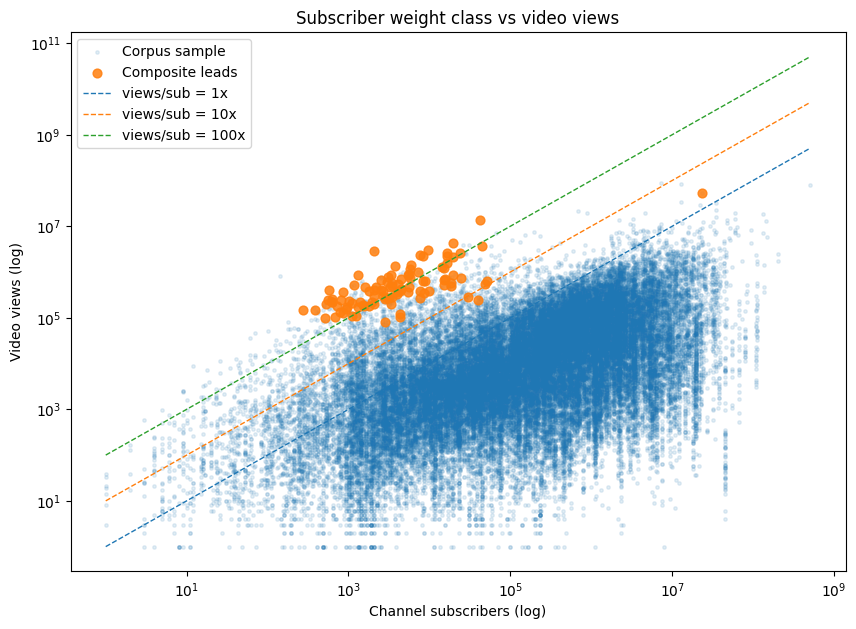

In [13]:
import matplotlib.pyplot as plt

plot_df = full_df[['video_id', 'subscribers', 'views', 'sub_class', 'views_per_sub']].copy()
plot_df['subscribers'] = pd.to_numeric(plot_df['subscribers'], errors='coerce')
plot_df['views'] = pd.to_numeric(plot_df['views'], errors='coerce')
plot_df = plot_df[(plot_df['subscribers'] > 0) & (plot_df['views'] > 0)]

# Downsample the 258k-row background so the notebook remains responsive.
background_plot = plot_df.sample(n=min(50_000, len(plot_df)), random_state=42)
lead_ids = set(composite_leads['video_id'].astype(str))
lead_plot = plot_df[plot_df['video_id'].astype(str).isin(lead_ids)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(background_plot['subscribers'], background_plot['views'], s=6, alpha=0.12, label='Corpus sample')
ax.scatter(lead_plot['subscribers'], lead_plot['views'], s=40, alpha=0.85, label='Composite leads')

x_min = max(plot_df['subscribers'].min(), 1)
x_max = plot_df['subscribers'].max()
x_values = np.logspace(np.log10(x_min), np.log10(x_max), 200)
for multiple in (1, 10, 100):
    ax.plot(x_values, x_values * multiple, linestyle='--', linewidth=1, label=f'views/sub = {multiple}x')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Channel subscribers (log)')
ax.set_ylabel('Video views (log)')
ax.set_title('Subscriber weight class vs video views')
ax.legend()
plt.show()

/tmp/ipykernel_534738/148484384.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=order, showfliers=False)


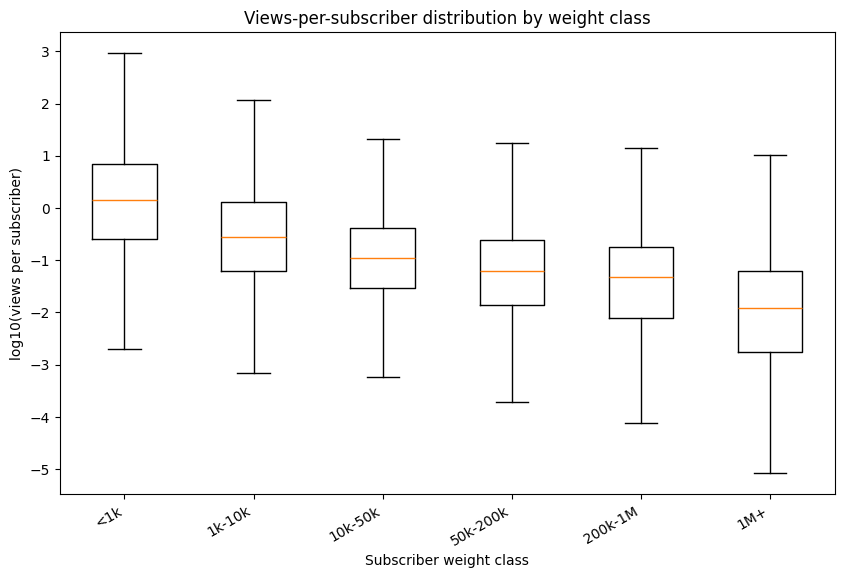

In [14]:
distribution_df = full_df[['sub_class', 'views_per_sub']].copy()
distribution_df['views_per_sub'] = pd.to_numeric(distribution_df['views_per_sub'], errors='coerce')
distribution_df = distribution_df[np.isfinite(distribution_df['views_per_sub']) & (distribution_df['views_per_sub'] > 0)]
distribution_df['log10_views_per_sub'] = np.log10(distribution_df['views_per_sub'].clip(lower=1e-6))

order = [label for label in metrics.SUB_WEIGHT_CLASSES if label in set(distribution_df['sub_class'].astype(str))]
box_data = [
    distribution_df.loc[distribution_df['sub_class'].astype(str).eq(label), 'log10_views_per_sub'].sample(
        n=min(20_000, distribution_df['sub_class'].astype(str).eq(label).sum()),
        random_state=42,
    )
    for label in order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(box_data, labels=order, showfliers=False)
ax.set_xlabel('Subscriber weight class')
ax.set_ylabel('log10(views per subscriber)')
ax.set_title('Views-per-subscriber distribution by weight class')
plt.xticks(rotation=30, ha='right')
plt.show()

## 8. Themes & Niches

`topics.extract_themes` finds recurring lead-title terms with lift versus the full background corpus. `topics.niche_saturation` summarizes categories where outliers concentrate. Read `saturation_score` as: high outlier rate plus comparatively few distinct channels means a potentially underserved niche.

In [15]:
theme_params = copy.deepcopy(PARAMS.get('topics', {}))
top_themes = topics.extract_themes(composite_leads, background=full_df, **theme_params).head(30)
display(top_themes)

niche_saturation = topics.niche_saturation(full_df, composite_leads, **theme_params)
display(niche_saturation)

,term,ngram_size,lead_count,lead_share,background_share,lift,median_views,median_views_per_sub,distinct_channels,example_titles,example_video_ids
0,birds movie,2,8,0.08,0.000245,359.463668,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | HsD6HJ_zMdo | 3AiBBkeqjBs
1,angry birds,2,8,0.08,0.000626,141.020362,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | HsD6HJ_zMdo | 3AiBBkeqjBs
2,flower man,2,4,0.04,0.000221,221.408781,240928.0,203.250217,4,Rubies man - Flower man but it's sung by Morsh...,xYVftJPcF0Y | 37BJRpCgw7M | BaYG3wJkYhs
3,angry,1,9,0.09,0.001256,78.044474,514716.0,308.414902,9,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | HsD6HJ_zMdo | 3AiBBkeqjBs
4,european fans,2,4,0.04,0.000380,128.921569,280205.0,180.658015,4,European Fans Mocked U.S. Stadiums… Until They...,I1UAMu3jrQ8 | GiBHHfoz1ZY | SUQrh0rTaLU
5,birds,1,8,0.08,0.001319,66.907471,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | HsD6HJ_zMdo | 3AiBBkeqjBs
6,flower,1,4,0.04,0.000467,104.997979,240928.0,203.250217,4,Rubies man - Flower man but it's sung by Morsh...,xYVftJPcF0Y | 37BJRpCgw7M | BaYG3wJkYhs
7,argentina,1,11,0.11,0.003817,30.824123,433917.0,81.273750,8,¿Por qué tantos celebran la derrota de Argenti...,yMcFzRG41Hc | 3j3aPhR0RZ8 | swo3KYo03_Y
8,fifa,1,11,0.11,0.003812,30.863042,389962.0,79.552961,7,FIFA Faces Massive Backlash As Spain vs Argent...,swo3KYo03_Y | Dn1s8difRtI | AKbc8VroSXM
9,europeans,1,9,0.09,0.003186,30.769800,205168.0,121.909804,8,Europeans Thought America's National Anthem Wa...,9nbV9CmCbEM | Yi5JJ4h7_Zs | cGV-9-IC-TY


,category_id,category_name,distinct_channels,outlier_channels,total_videos,outlier_videos,outlier_rate,median_outlier_subscribers,saturation_score
0,19,Travel & Events,209,2,1989,2,0.001006,2999.5,0.000188
1,28,Science & Technology,268,1,2869,3,0.001046,4380.0,0.000187
2,26,Howto & Style,233,2,2457,2,0.000814,13635.0,0.000149
3,22,People & Blogs,2464,38,38069,40,0.001051,2435.0,0.000135
4,23,Comedy,271,2,3350,2,0.000597,1841.5,0.000106
5,2,Autos & Vehicles,235,1,2302,1,0.000434,48500.0,0.000080
6,17,Sports,782,6,16165,8,0.000495,15200.0,0.000074
7,10,Music,1387,11,23109,11,0.000476,2790.0,0.000066
8,24,Entertainment,2422,14,35953,16,0.000445,6550.0,0.000057
9,27,Education,602,3,8572,3,0.000350,4050.0,0.000055


## 9. Export

In [16]:
if EXPORT:
    export_path = ra_leads.export_leads(composite_leads, EXPORT_PATH)
    composite_leads.attrs['export_path'] = str(export_path.resolve())
    print(f'Wrote composite leads CSV: {export_path.resolve()}')
else:
    composite_leads.attrs['export_path'] = None
    print('EXPORT is False; no CSV written.')

Wrote composite leads CSV: /home/orangepi/code_projects/skimmer/data/output/2026-07-31082319.csv


## 10. Checkpoint Cache

The slow load/enrich and scoring steps above are cached as Parquet in `data/cache/leads/`. Each entry is keyed by the database path, size, and modification time, by the analysis parameters, and by a hash of the `scripts/RecomendationAnalysis` sources, so new ingests, parameter changes, and algorithm edits all invalidate it automatically.

Use the cell below to inspect entries. Set `CLEAR_CACHE = True` to delete them, for example after many parameter sweeps have accumulated stale entries.


In [ ]:
CLEAR_CACHE = False  # Set True to delete cached checkpoints, then re-run this cell.
CLEAR_CACHE_KIND = None  # None clears every kind; use 'analysis_frame', 'algorithm_results', or 'raw_joined'.

if CLEAR_CACHE:
    removed = checkpoint.clear_cache(CACHE_DIR, kind=CLEAR_CACHE_KIND)
    print(f'Removed {removed} cached entries from {checkpoint.resolve_cache_dir(CACHE_DIR)}.')

cache_entries = checkpoint.describe_cache(CACHE_DIR)
print(f'Cache directory: {checkpoint.resolve_cache_dir(CACHE_DIR)}')
display(cache_entries if not cache_entries.empty else pd.DataFrame([{'note': 'cache is empty'}]))
